In [ ]:
if 'google.colab' in str(get_ipython()):
    ! git clone -b main https://github.com/edsonportosilva/OptiCommPy
    from os import chdir as cd
    cd('/content/OptiCommPy/')
    ! pip install .

In [ ]:
from tqdm.notebook import tqdm
import numpy as np
from numpy.fft import fft, ifft, fftfreq
from  scipy.constants import c,h
import matplotlib.pyplot as plt

from optic.comm.modulation import modulateGray, grayMapping
from optic.dsp.core import pnorm, upsample, firFilter, pulseShape, signal_power, phaseNoise, decimate, symbolSync
from optic.dsp.equalization import edc
from optic.models.devices import iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel, mzm
from optic.models.channels import linearFiberChannel, awgn, edfa
from optic.utils import parameters
from optic.plot import pconst, eyediagram, plotPSD
from optic.models.tx import simpleWDMTx
from optic.dsp.carrierRecovery import cpr

## Revisão e Implementação de Comunicações Ópticas
---

## Sumário
---
- [Revisão](#revisao)
- [Simulação WDM 64G PM-256QAM](#Simulação-WDM-64G-PM-256QAM)



### Revisão
  - _Modulação Óptica (MZM ou IQM)_: Pega o sinal elétrico do passo anterior e o usa para modificar as propriedades de uma onda de luz contínua vinda de um laser.
  - _Dispersão Cromática (CD – Chromatic Dispersion)_:  A luz branca é composta por várias frequências (ou comprimentos de onda). Em uma fibra, cada componente de frequência propaga com velocidade diferente, fazendo com que pulsos se espalhem no tempo. Alargamento dos pulsos ⇒ causa interferência entre símbolos (ISI).
  - _Dispersão por Modo de Polarização (PMD – Polarization Mode Dispersion)_: A fibra pode ter imperfeições que fazem a luz polarizada horizontal e verticalmente viajar em velocidades diferentes.  Um mesmo pulso se divide em dois, gerando atrasos e mistura entre os modos de polarização.
  - _Atenuação_:  Perda de potência do sinal devido à absorção e espalhamento na fibra. O sinal chega mais fraco ⇒ relação sinal-ruído (SNR) piora.
  - _Ruído de Amplificadores (ASE - Amplified Spontaneous Emission)_:  Amplificadores ópticos (como EDFA) geram ruído espontâneo junto ao sinal. Diminui o SNR.
  - _Ruído de fase (Phase Noise)_: O laser do transmissor e do receptor tem instabilidades na fase. A constelação gira e se espalha ao longo do tempo.
  - _Interferência entre símbolos (ISI)_: Pulsos consecutivos se sobrepõem devido a dispersão ou filtragem inadequada. Distorção dos símbolos ⇒ aumenta a BER (Bit Error Rate).
  - _Alargamento de pulso_: Espalhamento temporal do pulso, causado por dispersão (CD ou PMD).
  - _OSNR_: Optical Signal to Noise Ratio, mede a relação entre sinal e ruído óptico.
  - _BER_: Bit Error Rate, razão entre bits errados e transmitidos.
  - _Constelação_: Representação gráfica dos símbolos transmitidos no plano IQ.
  - _Filtro casado_: Filtro ideal para detectar pulsos (maximiza SNR na detecção).



In [ ]:
def rdeUp(x, constSymb, nModes, paramEq, y=None, e=None, w=None, preConv=False):
    """
    Radius-Directed Equalization Algorithm

    Returns
    -------
    tuple
        - y (np.array): estimativa dos símbolos.
        - e (np.array): erro associado a cada modo de polarização.
        - w (np.array): matriz de coeficientes.

    Referências
    -----------
    [1] Digital Coherent Optical Systems, Architecture and Algorithms
    """
    N = len(x) - paramEq.taps + 1

    # Obtém o atraso da filtragem FIR
    delay = (paramEq.taps - 1) // 2

    # obtem os raios da constelação M-QAM
    Rrde = np.unique(np.abs(constSymb))

    if preConv == False:

        paramEq.N2 = 0

        y = np.zeros((len(x), nModes), dtype='complex')
        e = np.zeros((len(x), nModes), dtype='complex')
        w = np.zeros((paramEq.taps, nModes**2), dtype='complex')

        # single spike initialization
        w[:,0][delay] = 1

    for n in tqdm(range(paramEq.N2, N), disable=not (paramEq.progBar)):

        xH = np.flipud(x[:,0][n:n+paramEq.taps])
        xV = np.flipud(x[:,1][n:n+paramEq.taps])

        # calcula a saída do equalizador 2x2
        y[:,0][n] = np.dot(w[:,0], xV) + np.dot(w[:,1], xH)
        y[:,1][n] = np.dot(w[:,2], xV) + np.dot(w[:,3], xH)

        R1 = np.argmin(np.abs(Rrde - np.abs(y[:,0][n])))
        R2 = np.argmin(np.abs(Rrde - np.abs(y[:,1][n])))

        # calcula e atualiza erro para cada modo de polarização
        e[:,0][n] = y[:,0][n] * (Rrde[R1]**2 - np.abs(y[:,0][n])**2)
        e[:,1][n] = y[:,1][n] * (Rrde[R2]**2 - np.abs(y[:,1][n])**2)

        # atualiza os coeficientes do equalizador
        w[:,0] += paramEq.lr[1] * np.conj(xV) * e[:,0][n]
        w[:,2] += paramEq.lr[1] * np.conj(xV) * e[:,1][n]
        w[:,1] += paramEq.lr[1] * np.conj(xH) * e[:,0][n]
        w[:,3] += paramEq.lr[1] * np.conj(xH) * e[:,1][n]

        if n == paramEq.N1:
            # Defina a polarização Y como ortogonal a X para evitar
            # a convergência para a mesma polarização (evitar a singularidade CMA)
            w[:,3] =  np.conj(w[:,0][::-1])
            w[:,2] = -np.conj(w[:,1][::-1])

    return y, e, w

In [ ]:
def cmaUp(x, constSymb, nModes, paramEq, preConv=False):
    """
    Constant-Modulus Algorithm

    Returns
    -------
    tuple
        - y (np.array): estimativa dos símbolos.
        - e (np.array): erro associado a cada modo de polarização.
        - w (np.array): matriz de coeficientes.

    Referências
    -----------
    [1] Digital Coherent Optical Systems, Architecture and Algorithms
    """

    N = len(x) - paramEq.taps + 1

    # Obtém o atraso da filtragem FIR
    delay = (paramEq.taps - 1) // 2

    y = np.zeros((len(x), nModes), dtype='complex')
    e = np.zeros((len(x), nModes), dtype='complex')
    w = np.zeros((paramEq.taps, nModes**2), dtype='complex')

    # single spike initialization
    w[:,0][delay] = 1

    # constante relacionada às características da modulação para o algoritmo CMA
    R = np.mean(np.abs(constSymb)**4) / np.mean(np.abs(constSymb)**2)

    for n in tqdm(range(N), disable=not (paramEq.progBar)):

        xH = np.flipud(x[:,0][n:n+paramEq.taps])
        xV = np.flipud(x[:,1][n:n+paramEq.taps])

        # calcula a saída do equalizador 2x2
        y[:,0][n] = np.dot(w[:,0], xV) + np.dot(w[:,1], xH)
        y[:,1][n] = np.dot(w[:,2], xV) + np.dot(w[:,3], xH)

        # calcula e atualiza erro para cada modo de polarização
        e[:,0][n] = y[:,0][n] * (R - np.abs(y[:,0][n])**2)
        e[:,1][n] = y[:,1][n] * (R - np.abs(y[:,1][n])**2)

        # atualiza os coeficientes do filtro
        w[:,0] += paramEq.lr[0] * np.conj(xV) * e[:,0][n]
        w[:,2] += paramEq.lr[0] * np.conj(xV) * e[:,1][n]
        w[:,1] += paramEq.lr[0] * np.conj(xH) * e[:,0][n]
        w[:,3] += paramEq.lr[0] * np.conj(xH) * e[:,1][n]

        if n == paramEq.N1:
            # Defina a polarização Y como ortogonal a X para evitar
            # a convergência para a mesma polarização (evitar a singularidade CMA)
            w[:,3] =  np.conj(w[:,0][::-1])
            w[:,2] = -np.conj(w[:,1][::-1])

        if preConv and n == paramEq.N2:
            break

    if preConv:
        w = w/np.max(np.abs(w))
        y, e, w = rdeUp(x, constSymb, nModes, paramEq, y, e, w, preConv=True)

    return y, e, w

In [ ]:
def mimoAdaptEq(x, paramEq):
    """
    Equalizador adaptativo MIMO 2x2

    Returns
    -------
    tuple
        - y (np.array): estimativa dos símbolos.
        - e (np.array): erro associado a cada modo de polarização.
        - w (np.array): matriz de coeficientes.

    Raises
    ------
    ValueError
        Caso o sinal não possua duas polarizações.

    ValueError
        Caso o algoritmo seja especificado incorretamente.
    """

    if x.shape[1] != 2:
        raise ValueError("O sinal deve conter duas polarizações")

    nModes = x.shape[1]

    # obtem os símbolos da constelação
    constSymb = grayMapping(paramEq.M, paramEq.constType)
    # normaliza os símbolos da constelação
    constSymb = pnorm(constSymb)

    if paramEq.alg == 'cma':
        y, e, w = cmaUp(x, constSymb, nModes, paramEq)
    elif paramEq.alg == 'rde':
        y, e, w = rdeUp(x, constSymb, nModes, paramEq)
    elif paramEq.alg == 'cma-to-rde':
        y, e, w = cmaUp(x, constSymb, nModes, paramEq, preConv=True)
    else:
        raise ValueError("Algoritmo de equalização especificado incorretamente.")

    return y, e, w

### Simulação WDM 64G PM-256QAM
Nesta implementação, simulamos uma cadeia completa de transmissão óptica coerente baseada em modulação PM-64QAM (Polarization-Multiplexed 256-QAM), uma das modulações avançadas utilizadas em sistemas de alta capacidade. O objetivo é aproximar o comportamento do sistema às condições reais, incorporando efeitos físicos típicos da fibra óptica, como:

  - Dispersão cromática (CD) — que causa alargamento dos pulsos no tempo.

  - Mistura de polarizações — causada por rotação de polarização no canal, representando efeitos de PMD (Polarization Mode Dispersion).

  - Ruído aditivo gaussiano (ASE) — modelando o impacto de amplificadores ópticos como o EDFA.

  - Ruído de fase — devido à largura de linha finita dos lasers no transmissor e receptor.

Para recuperar a qualidade do sinal no receptor, é utilizado um front-end coerente com dois modos de polarização (MIMO 2×2) e um processo de equalização adaptativa:

  - CMA (Constant Modulus Algorithm) para pré-convergência cega,
seguido por RDE (Radius Directed Equalization), mais sensível à topologia de constelações multirraio (cma-to-rde).

A recuperação da fase (CPR) também é aplicada ao final, compensando os efeitos residuais de rotação do sinal na constelação.

In [ ]:
############## Parâmetros ##############

# Parametros usados para gerar e modular sinais
paramTx           = parameters()
paramTx.M         = 256                                                         # Ordem de modulação (256-QAM)
paramTx.constType = "qam"                                                       # Tipo de modulação
paramTx.pulse     = "rrc"                                                       # Tipo de pulso
paramTx.Ntaps     = 4096                                                        # Número de coeficientes do pulso
paramTx.alphaRRC  = 0.01                                                        # Rolloff do pulso RRC baixo para permitir uma alttíssima eficiencia espectral
paramTx.Rs        = 64e9                                                        # Taxa de simbolos/ Largura de banda: 64Gb
paramTx.SpS       = 32                                                          # Amostras por símbolos
paramTx.Fc        = 193.1e12                                                    # Frequência central
paramTx.lw        = 100e3                                                       # laser linewidth
paramTx.Pch_dBm   = 0                                                           # Potência por canal (em dBm)
paramTx.Nch       = 3                                                           # Canais WDM
paramTx.freqSpac  = 50e9                                                        # Espaçamento de grade
paramTx.Nmodes    = 2                                                           # PM (dois modos)
paramTx.Nbits     = int(np.log2(paramTx.M) * 2e5)                               # Número bits por polarização

Fs = paramTx.Rs * paramTx.SpS                                                   # Frequência de amostragem

# Parametros da fibra, valores serão usados para simular dispersão e perdas
paramFiber        = parameters()
paramFiber.L      = 1000                                                        # Comprimento total da fibra
paramFiber.alpha  = 0.2                                                         # Parametro de perdas => 0.2 dB/km
paramFiber.D      = 17                                                          # Parametro de Dispersão cromática típica
paramFiber.Fs     = Fs

# Parametros usados para simular o sinal com o Laser LO
paramLO = parameters()
paramLO.P = 10                                                                  # Potência óptica do laser do LO (em dBm)
paramLO.lw = 100e3                                                              # Define a largura de linha
paramLO.RIN_var = 0                                                             # Variância do ruído aditivo
paramLO.Fs = Fs

# Define os parâmetros do receptor coerente
paramPD = parameters()
paramPD.B = paramTx.Rs
paramPD.Fs = Fs
paramPD.ideal = True

In [ ]:
############## Transmissão e modulação ##############

sigWDMTx, SymbTx, paramTx = simpleWDMTx(paramTx)

############## Canal Óptico ##############
# Adiciona EDFA para compensar perdas
paramEDFA = parameters()
paramEDFA.G = paramFiber.alpha * paramFiber.L                                   # Ganho para compensar
paramEDFA.Fs = Fs
paramEDFA.NF = 12
paramEDFA.Fc = paramTx.Fc                                                       # Calcula a frequência central                                                        # Transformando dB/km em (gain)dB
sigCh = edfa(sigWDMTx, paramEDFA)                                               # modelo linear do EDFA

# Simulação do canal linear
sigCh = linearFiberChannel(sigCh, paramFiber)

  0%|          | 0/3 [00:00<?, ?it/s]

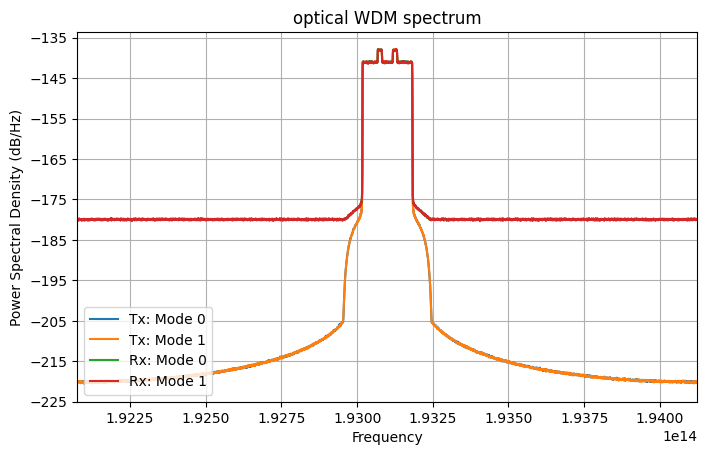

In [ ]:
# plot psd
fig,_ = plotPSD(sigWDMTx, Fs, paramFiber.Fc, label='Tx');
fig, ax = plotPSD(sigCh, Fs, paramFiber.Fc, fig=fig, label='Rx');
fig.set_figwidth(8)
ax.set_title('optical WDM spectrum');

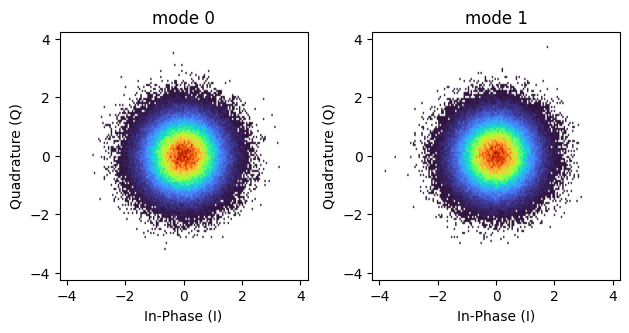

In [ ]:
############## Receptor Óptico (PMD)##############

# local oscillator (LO) parameters:
f0 = 150e6                                                                      # Frequencia offset
df_lo = paramTx.freqGrid[0] + f0
t = np.arange(0, sigCh.shape[0]) / Fs
paramLO.Ns = len(sigCh)
sigLO = basicLaserModel(paramLO)                                                # Gerando o Laser com suas Imperfeições
sigLO = sigLO*np.exp(1j*2*np.pi*df_lo*t)                                        # Simulando o Deslocamento de Frequência

# Rotação de polarização para simular PMD
θsig = np.pi/3
sigRx = pdmCoherentReceiver(sigCh, sigLO, θsig, paramPD)

# plot received constellations
pconst(sigRx[0::paramTx.SpS], R=3);

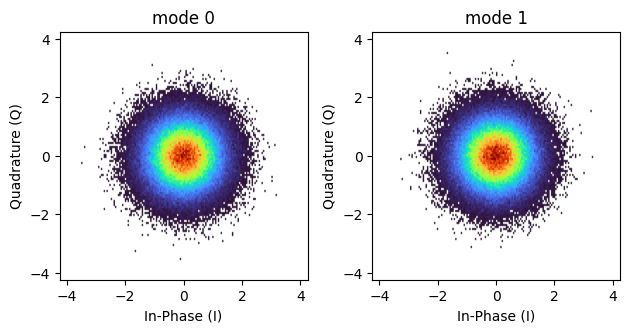

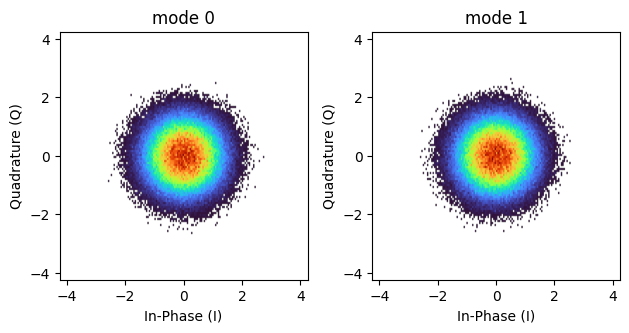

In [ ]:
############## Filtro Casado e Compensação de CD ##############

# Filtro Casado
if paramTx.pulse == 'nrz':
    pulse = pulseShape('nrz', paramTx.SpS)
elif paramTx.pulse == 'rrc':
    pulse = pulseShape('rrc', paramTx.SpS, N=paramTx.Ntaps, alpha=paramTx.alphaRRC, Ts=1/paramTx.Rs)

pulse = pnorm(pulse)
sigRx = firFilter(pulse, sigRx)

# plot constellations after matched filtering
pconst(sigRx[0::paramTx.SpS,:], R=3)

# CD compensation
paramEDC = parameters()
paramEDC.L = paramFiber.L
paramEDC.D = paramFiber.D
paramEDC.Fc = paramFiber.Fc-df_lo
paramEDC.Fs = Fs

sigRx = edc(sigRx, paramEDC)
pconst(sigRx[0::paramTx.SpS,:], R=3);

  0%|          | 0/199992 [00:00<?, ?it/s]

  0%|          | 0/184992 [00:00<?, ?it/s]

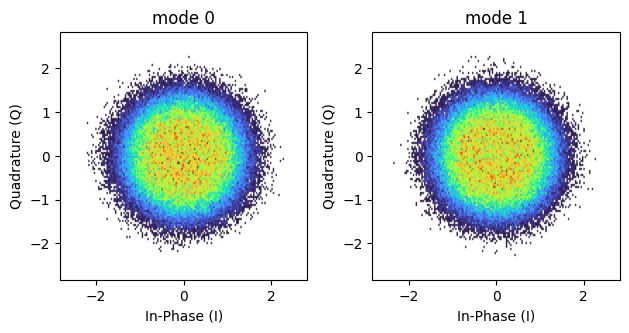

  0%|          | 0/199992 [00:00<?, ?it/s]

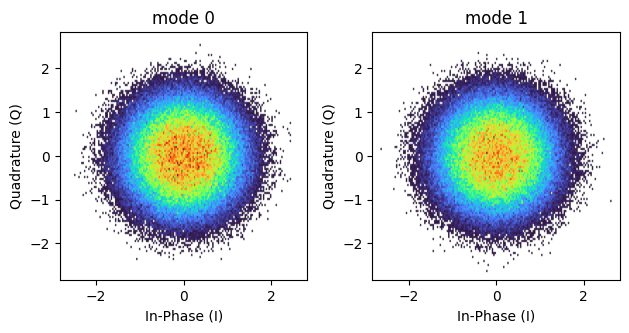

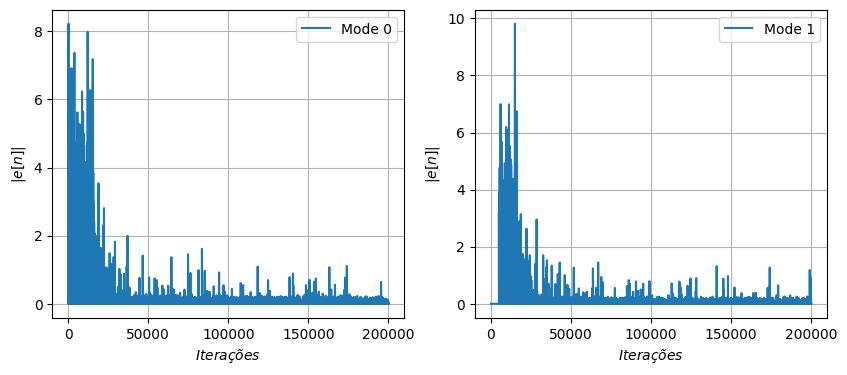

In [ ]:
# decimate to one sample per symbol
paramDec = parameters()
paramDec.SpS_in  = paramTx.SpS
paramDec.SpS_out = 1
sigRx = decimate(sigRx, paramDec)

x = pnorm(sigRx)

# parâmetros do equalizador
paramEq = parameters()
paramEq.taps = 9
paramEq.lr   = [5e-3, 1e-3] # [cma, rde]
paramEq.N1   = 5000
paramEq.N2   = 15000
paramEq.M    = paramTx.M
paramEq.constType = 'qam' # paramTx.constType
paramEq.progBar = True

if paramTx.M == 4:
    paramEq.alg = 'cma' # QPSK
else:
    paramEq.alg = 'cma-to-rde' # QAM

y_EQ, Error, W = mimoAdaptEq(x, paramEq)

discard = 40000
pconst(y_EQ[discard:-discard,:], R=2);

# sem pre-convergência
paramEq.alg = 'rde'
y_RDE, _, _ = mimoAdaptEq(x, paramEq)

discard = 20000
pconst(y_RDE[discard:-discard,:], R=2);


fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(np.abs(Error[:, 0]), label='Mode 0')
axs[0].set_ylabel(r'$|e{[n]}|$')
axs[0].set_xlabel(r'$Iterações$')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(np.abs(Error[:, 1]), label='Mode 1')
axs[1].set_ylabel(r'$|e{[n]}|$')
axs[1].set_xlabel(r'$Iterações$')
axs[1].legend()
axs[1].grid(True)

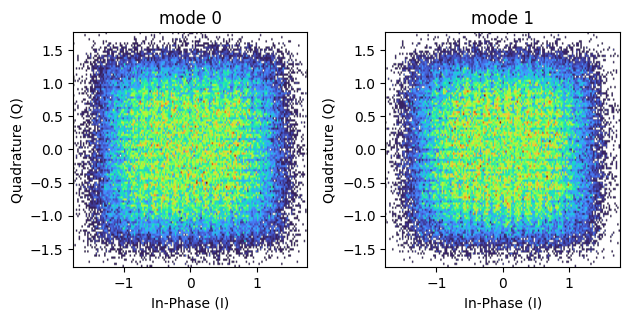


Equalização sem pre-convergência


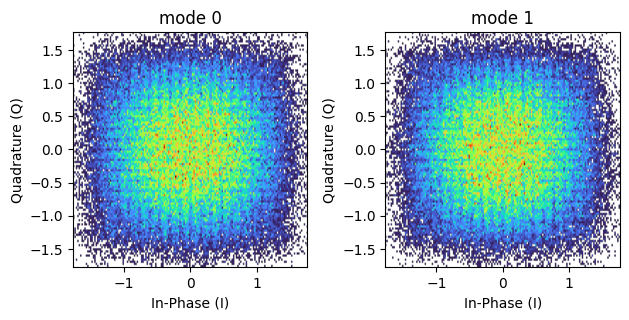

In [ ]:
paramCPR = parameters()
paramCPR.alg = 'bps'
paramCPR.M   = paramTx.M
paramCPR.N   = 75
paramCPR.B   = 64

y_CPR     = cpr(y_EQ, paramCPR)
y_CPR_RDE = cpr(y_RDE, paramCPR)

#d = pnorm(symbTx)
discard = 40000

#plot constellations after CPR
pconst(y_CPR[discard:-discard,:]);

print('\nEqualização sem pre-convergência')
pconst(y_CPR_RDE[discard:-discard,:]);